In [ ]:
import torch
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Minimal DSL Wrapper

In [ ]:
class FusionBlock:
    def __init__(self, fn):
        self.fn = fn
        self.compiled_fn = torch.compile(fn, mode="reduce-overhead")

    def __call__(self, *args, **kwargs):
        return self.compiled_fn(*args, **kwargs)

def fusion_block(fn):
    return FusionBlock(fn)

Baseline and DSL Versions

In [ ]:
def eager_chain(x):
    y = torch.sin(x)
    y = torch.cos(y)
    y = torch.exp(y)
    y = torch.relu(y)
    return y

@fusion_block
def fused_chain(x):
    y = torch.sin(x)
    y = torch.cos(y)
    y = torch.exp(y)
    y = torch.relu(y)
    return y

Benchmark Helper Function

In [ ]:
def benchmark(fn, x, warmup=10, iters=100):
    for _ in range(warmup):
        y = fn(x)
    torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(iters):
        y = fn(x)
    torch.cuda.synchronize()

    end = time.perf_counter()
    return (end - start) / iters

Preliminary Results

In [ ]:
sizes = [10_000, 100_000, 1_000_000, 10_000_000]
results = []

for n in sizes:
    x = torch.randn(n, device=device)

    eager_time = benchmark(eager_chain, x)
    fused_time = benchmark(fused_chain, x)

    speedup = eager_time / fused_time

    results.append({
        "Tensor Size": n,
        "Eager Time (ms)": eager_time * 1000,
        "DSL/Fused Time (ms)": fused_time * 1000,
        "Speedup": speedup
    })

df = pd.DataFrame(results)
df

,Tensor Size,Eager Time (ms),DSL/Fused Time (ms),Speedup
0,10000,0.031428,0.126817,0.247824
1,100000,0.047549,0.102651,0.463210
2,1000000,0.141975,0.101228,1.402527
3,10000000,1.348196,0.739395,1.823378


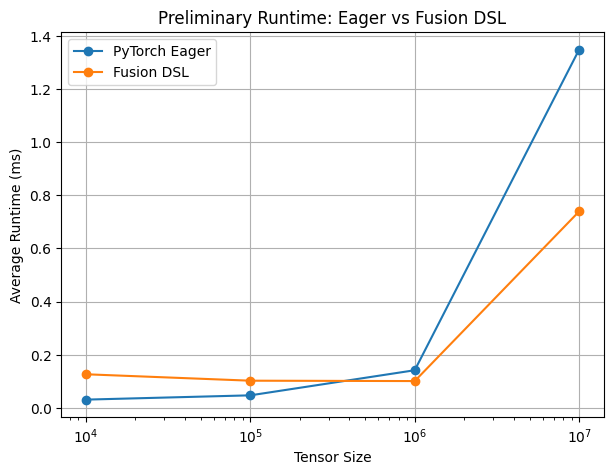

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(df["Tensor Size"], df["Eager Time (ms)"], marker="o", label="PyTorch Eager")
plt.plot(df["Tensor Size"], df["DSL/Fused Time (ms)"], marker="o", label="Fusion DSL")
plt.xscale("log")
plt.xlabel("Tensor Size")
plt.ylabel("Average Runtime (ms)")
plt.title("Preliminary Runtime: Eager vs Fusion DSL")
plt.legend()
plt.grid(True)
plt.savefig("runtime_plot.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
x = torch.randn(1000, device=device)

eager_out = eager_chain(x)
fused_out = fused_chain(x)

print("Outputs close:", torch.allclose(eager_out, fused_out, atol=1e-5))
print("Max difference:", (eager_out - fused_out).abs().max().item())

Outputs close: True
Max difference: 0.0


Binary Operations

In [ ]:
def eager_mixed_chain(x):
    y = torch.sin(x) # unary
    y = y + x # binary elementwise add
    y = y * 0.5 # binary scalar multiply
    y = torch.cos(y) # unary
    y = y + 1.0 # binary scalar add
    y = torch.exp(y) # unary
    y = torch.relu(y) # unary
    return y

@fusion_block
def fused_mixed_chain(x):
    y = torch.sin(x)
    y = y + x
    y = y * 0.5
    y = torch.cos(y)
    y = y + 1.0
    y = torch.exp(y)
    y = torch.relu(y)
    return y

In [ ]:
x = torch.randn(1000, device=device)

eager_out = eager_mixed_chain(x)
fused_out = fused_mixed_chain(x)

print("Mixed chain outputs close:", torch.allclose(eager_out, fused_out, atol=1e-5))
print("Mixed chain max difference:", (eager_out - fused_out).abs().max().item())

Mixed chain outputs close: True
Mixed chain max difference: 0.0


In [ ]:
sizes = [10_000, 100_000, 1_000_000, 10_000_000]
mixed_results = []

for n in sizes:
    x = torch.randn(n, device=device)

    eager_time = benchmark(eager_mixed_chain, x)
    fused_time = benchmark(fused_mixed_chain, x)

    mixed_results.append({
        "Tensor Size": n,
        "Eager Time (ms)": eager_time * 1000,
        "DSL/Fused Time (ms)": fused_time * 1000,
        "Speedup": eager_time / fused_time
    })

mixed_df = pd.DataFrame(mixed_results)
mixed_df

,Tensor Size,Eager Time (ms),DSL/Fused Time (ms),Speedup
0,10000,0.078042,0.115186,0.677529
1,100000,0.068640,0.102744,0.668064
2,1000000,0.264743,0.099790,2.653008
3,10000000,2.514520,0.717232,3.505868


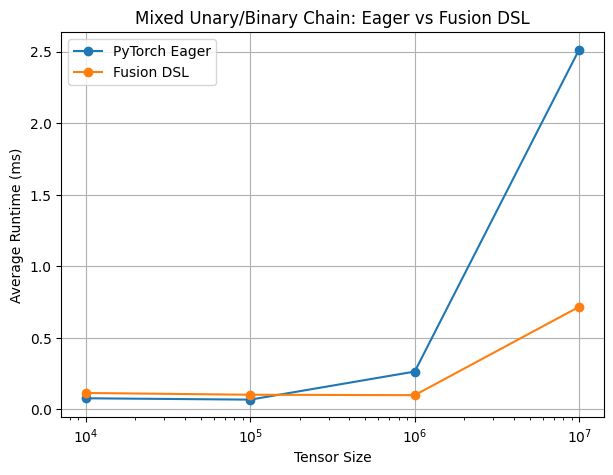

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(mixed_df["Tensor Size"], mixed_df["Eager Time (ms)"], marker="o", label="PyTorch Eager")
plt.plot(mixed_df["Tensor Size"], mixed_df["DSL/Fused Time (ms)"], marker="o", label="Fusion DSL")
plt.xscale("log")
plt.xlabel("Tensor Size")
plt.ylabel("Average Runtime (ms)")
plt.title("Mixed Unary/Binary Chain: Eager vs Fusion DSL")
plt.legend()
plt.grid(True)
plt.savefig("mixed_chain_runtime.png", dpi=200, bbox_inches="tight")
plt.show()

Dictionary of Benchmark Functions

In [ ]:
# benchmark 1: short unary chain
def eager_unary_short(x):
    return torch.relu(torch.exp(torch.cos(torch.sin(x))))

@fusion_block
def fused_unary_short(x):
    return torch.relu(torch.exp(torch.cos(torch.sin(x))))

# benchmark 2: mixed unary and binary chain
def eager_mixed_chain(x):
    y = torch.sin(x)
    y = y + x
    y = y * 0.5
    y = torch.cos(y)
    y = y + 1.0
    y = torch.exp(y)
    y = torch.relu(y)
    return y

@fusion_block
def fused_mixed_chain(x):
    y = torch.sin(x)
    y = y + x
    y = y * 0.5
    y = torch.cos(y)
    y = y + 1.0
    y = torch.exp(y)
    y = torch.relu(y)
    return y

# benchmark 3: longer elementwise chain
def eager_long_chain(x):
    y = torch.sin(x)
    y = torch.cos(y)
    y = y + 0.25
    y = torch.tanh(y)
    y = y * 1.5
    y = torch.exp(y)
    y = torch.sqrt(torch.abs(y) + 1e-6)
    y = torch.relu(y)
    return y

@fusion_block
def fused_long_chain(x):
    y = torch.sin(x)
    y = torch.cos(y)
    y = y + 0.25
    y = torch.tanh(y)
    y = y * 1.5
    y = torch.exp(y)
    y = torch.sqrt(torch.abs(y) + 1e-6)
    y = torch.relu(y)
    return y

Running All Benchmarks

In [ ]:
benchmarks = {
    "Unary Short": (eager_unary_short, fused_unary_short),
    "Mixed Unary/Binary": (eager_mixed_chain, fused_mixed_chain),
    "Long Chain": (eager_long_chain, fused_long_chain),
}

sizes = [10_000, 100_000, 1_000_000, 10_000_000]
all_results = []

for bench_name, (eager_fn, fused_fn) in benchmarks.items():
    for n in sizes:
        x = torch.randn(n, device=device)

        eager_time = benchmark(eager_fn, x)
        fused_time = benchmark(fused_fn, x)

        eager_out = eager_fn(x)
        fused_out = fused_fn(x)
        correct = torch.allclose(eager_out, fused_out, atol=1e-5)

        all_results.append({
            "Benchmark": bench_name,
            "Tensor Size": n,
            "Eager Time (ms)": eager_time * 1000,
            "DSL/Fused Time (ms)": fused_time * 1000,
            "Speedup": eager_time / fused_time,
            "Correct": correct
        })

all_df = pd.DataFrame(all_results)
all_df

,Benchmark,Tensor Size,Eager Time (ms),DSL/Fused Time (ms),Speedup,Correct
0,Unary Short,10000,0.047198,0.101016,0.467228,True
1,Unary Short,100000,0.035676,0.102659,0.347520,True
2,Unary Short,1000000,0.137267,0.107413,1.277941,True
3,Unary Short,10000000,1.380017,0.694414,1.987310,True
4,Mixed Unary/Binary,10000,0.071513,0.095907,0.745653,True
5,Mixed Unary/Binary,100000,0.064726,0.101463,0.637926,True
6,Mixed Unary/Binary,1000000,0.257082,0.092493,2.779470,True
7,Mixed Unary/Binary,10000000,2.579599,0.680650,3.789907,True
8,Long Chain,10000,0.107310,0.085919,1.248962,True
9,Long Chain,100000,0.097052,0.094918,1.022482,True


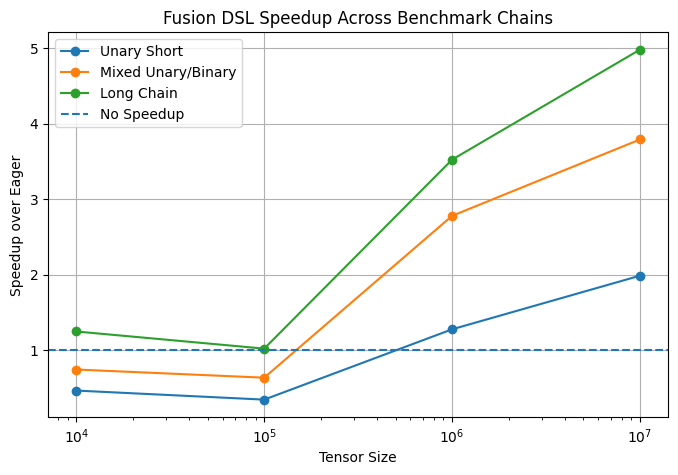

In [ ]:
plt.figure(figsize=(8, 5))

for bench_name in all_df["Benchmark"].unique():
    subset = all_df[all_df["Benchmark"] == bench_name]
    plt.plot(subset["Tensor Size"], subset["Speedup"], marker="o", label=bench_name)

plt.axhline(y=1.0, linestyle="--", label="No Speedup")
plt.xscale("log")
plt.xlabel("Tensor Size")
plt.ylabel("Speedup over Eager")
plt.title("Fusion DSL Speedup Across Benchmark Chains")
plt.legend()
plt.grid(True)
plt.savefig("benchmark_speedups.png", dpi=200, bbox_inches="tight")
plt.show()

Memory Benchmark

In [ ]:
def benchmark_memory(fn, x):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    y = fn(x)

    torch.cuda.synchronize()

    peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)

    return peak_mem

Eager vs. Fused

In [ ]:
x = torch.randn(10_000_000, device=device)

eager_mem = benchmark_memory(eager_long_chain, x)
fused_mem = benchmark_memory(fused_long_chain, x)

print("Eager Peak Memory (MB):", eager_mem)
print("Fused Peak Memory (MB):", fused_mem)

Eager Peak Memory (MB): 190.73583984375
Fused Peak Memory (MB): 76.294921875


Adding Memory to Benchmark Loop

In [ ]:
all_results = []

for bench_name, (eager_fn, fused_fn) in benchmarks.items():
    for n in sizes:

        x = torch.randn(n, device=device)

        eager_time = benchmark(eager_fn, x)
        fused_time = benchmark(fused_fn, x)

        eager_mem = benchmark_memory(eager_fn, x)
        fused_mem = benchmark_memory(fused_fn, x)

        eager_out = eager_fn(x)
        fused_out = fused_fn(x)

        correct = torch.allclose(eager_out, fused_out, atol=1e-5)

        all_results.append({
            "Benchmark": bench_name,
            "Tensor Size": n,

            "Eager Time (ms)": eager_time * 1000,
            "DSL/Fused Time (ms)": fused_time * 1000,

            "Eager Peak Mem (MB)": eager_mem,
            "DSL/Fused Peak Mem (MB)": fused_mem,

            "Speedup": eager_time / fused_time,
            "Correct": correct
        })

all_df = pd.DataFrame(all_results)
all_df

,Benchmark,Tensor Size,Eager Time (ms),DSL/Fused Time (ms),Eager Peak Mem (MB),DSL/Fused Peak Mem (MB),Speedup,Correct
0,Unary Short,10000,0.077075,0.147677,38.263672,38.186523,0.521913,True
1,Unary Short,100000,0.047912,0.157435,1.185059,0.421387,0.304327,True
2,Unary Short,1000000,0.137561,0.151384,11.827637,4.197754,0.908685,True
3,Unary Short,10000000,1.384345,0.694303,118.256836,41.962891,1.993863,True
4,Mixed Unary/Binary,10000,0.091500,0.147408,38.263672,38.186523,0.620724,True
5,Mixed Unary/Binary,100000,0.091609,0.145640,1.185059,0.421387,0.629013,True
6,Mixed Unary/Binary,1000000,0.257249,0.159773,11.827637,4.197754,1.610091,True
7,Mixed Unary/Binary,10000000,2.578529,0.681295,118.256836,41.962891,3.784750,True
8,Long Chain,10000,0.138120,0.146399,38.302246,38.186523,0.943446,True
9,Long Chain,100000,0.137147,0.156364,1.566895,0.421387,0.877101,True


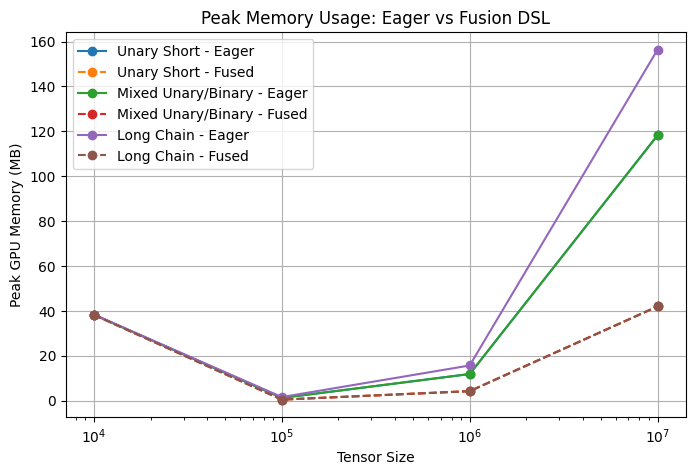

In [ ]:
plt.figure(figsize=(8, 5))

for bench_name in all_df["Benchmark"].unique():

    subset = all_df[all_df["Benchmark"] == bench_name]

    plt.plot(
        subset["Tensor Size"],
        subset["Eager Peak Mem (MB)"],
        marker="o",
        label=f"{bench_name} - Eager"
    )

    plt.plot(
        subset["Tensor Size"],
        subset["DSL/Fused Peak Mem (MB)"],
        marker="o",
        linestyle="--",
        label=f"{bench_name} - Fused"
    )

plt.xscale("log")
plt.xlabel("Tensor Size")
plt.ylabel("Peak GPU Memory (MB)")
plt.title("Peak Memory Usage: Eager vs Fusion DSL")
plt.legend()
plt.grid(True)

plt.savefig("memory_usage.png", dpi=200, bbox_inches="tight")
plt.show()

Direct torch.compile Baseline

In [ ]:
compiled_unary_short = torch.compile(eager_unary_short, mode="reduce-overhead")
compiled_mixed_chain = torch.compile(eager_mixed_chain, mode="reduce-overhead")
compiled_long_chain = torch.compile(eager_long_chain, mode="reduce-overhead")

In [ ]:
benchmarks = {
    "Unary Short": {
        "Eager": eager_unary_short,
        "torch.compile": compiled_unary_short,
        "Fusion DSL": fused_unary_short,
    },
    "Mixed Unary/Binary": {
        "Eager": eager_mixed_chain,
        "torch.compile": compiled_mixed_chain,
        "Fusion DSL": fused_mixed_chain,
    },
    "Long Chain": {
        "Eager": eager_long_chain,
        "torch.compile": compiled_long_chain,
        "Fusion DSL": fused_long_chain,
    },
}

In [ ]:
sizes = [10_000, 100_000, 1_000_000, 10_000_000]
all_results = []

for bench_name, versions in benchmarks.items():
    for n in sizes:
        x = torch.randn(n, device=device)

        eager_out = versions["Eager"](x)

        for version_name, fn in versions.items():
            runtime = benchmark(fn, x)
            peak_mem = benchmark_memory(fn, x)

            out = fn(x)
            correct = torch.allclose(eager_out, out, atol=1e-5)

            all_results.append({
                "Benchmark": bench_name,
                "Tensor Size": n,
                "Version": version_name,
                "Runtime (ms)": runtime * 1000,
                "Peak Mem (MB)": peak_mem,
                "Correct": correct
            })

all_df = pd.DataFrame(all_results)
all_df

,Benchmark,Tensor Size,Version,Runtime (ms),Peak Mem (MB),Correct
0,Unary Short,10000,Eager,0.049304,0.155273,True
1,Unary Short,10000,torch.compile,0.097883,0.116699,True
2,Unary Short,10000,Fusion DSL,0.130159,0.078125,True
3,Unary Short,100000,Eager,0.035137,1.528320,True
4,Unary Short,100000,torch.compile,0.111559,1.146484,True
5,Unary Short,100000,Fusion DSL,0.108301,0.764648,True
6,Unary Short,1000000,Eager,0.136738,15.260742,True
7,Unary Short,1000000,torch.compile,0.155894,11.445801,True
8,Unary Short,1000000,Fusion DSL,0.130970,7.630859,True
9,Unary Short,10000000,Eager,1.383894,152.588867,True


In [ ]:
eager_times = (
    all_df[all_df["Version"] == "Eager"]
    .set_index(["Benchmark", "Tensor Size"])["Runtime (ms)"]
)

all_df["Speedup vs Eager"] = all_df.apply(
    lambda row: eager_times.loc[(row["Benchmark"], row["Tensor Size"])] / row["Runtime (ms)"],
    axis=1
)

all_df

,Benchmark,Tensor Size,Version,Runtime (ms),Peak Mem (MB),Correct,Speedup vs Eager
0,Unary Short,10000,Eager,0.049304,0.155273,True,1.000000
1,Unary Short,10000,torch.compile,0.097883,0.116699,True,0.503703
2,Unary Short,10000,Fusion DSL,0.130159,0.078125,True,0.378798
3,Unary Short,100000,Eager,0.035137,1.528320,True,1.000000
4,Unary Short,100000,torch.compile,0.111559,1.146484,True,0.314961
5,Unary Short,100000,Fusion DSL,0.108301,0.764648,True,0.324434
6,Unary Short,1000000,Eager,0.136738,15.260742,True,1.000000
7,Unary Short,1000000,torch.compile,0.155894,11.445801,True,0.877120
8,Unary Short,1000000,Fusion DSL,0.130970,7.630859,True,1.044044
9,Unary Short,10000000,Eager,1.383894,152.588867,True,1.000000


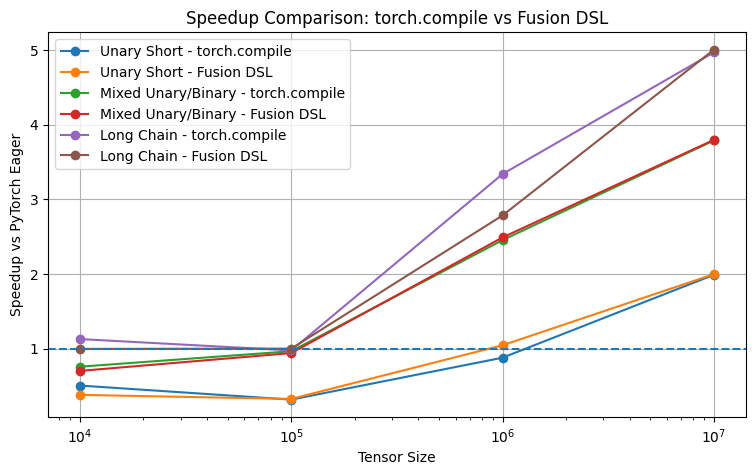

In [ ]:
plt.figure(figsize=(9, 5))

for bench_name in all_df["Benchmark"].unique():
    subset = all_df[
        (all_df["Benchmark"] == bench_name) &
        (all_df["Version"] != "Eager")
    ]

    for version_name in subset["Version"].unique():
        version_subset = subset[subset["Version"] == version_name]

        plt.plot(
            version_subset["Tensor Size"],
            version_subset["Speedup vs Eager"],
            marker="o",
            label=f"{bench_name} - {version_name}"
        )

plt.axhline(y=1.0, linestyle="--")
plt.xscale("log")
plt.xlabel("Tensor Size")
plt.ylabel("Speedup vs PyTorch Eager")
plt.title("Speedup Comparison: torch.compile vs Fusion DSL")
plt.legend()
plt.grid(True)
plt.savefig("multi_baseline_speedup.png", dpi=200, bbox_inches="tight")
plt.show()

Chain-length Ablation Study

In [ ]:
def make_chain(num_ops):
    def chain(x):
        y = x
        for i in range(num_ops):
            if i % 4 == 0:
                y = torch.sin(y)
            elif i % 4 == 1:
                y = torch.cos(y)
            elif i % 4 == 2:
                y = y + 0.5
            else:
                y = torch.relu(y)
        return y
    return chain

In [ ]:
chain_lengths = [2, 4, 8, 12]
ablation_results = []

for length in chain_lengths:
    eager_fn = make_chain(length)
    compiled_fn = torch.compile(eager_fn, mode="reduce-overhead")

    @fusion_block
    def fused_fn(x, length=length):
        y = x
        for i in range(length):
            if i % 4 == 0:
                y = torch.sin(y)
            elif i % 4 == 1:
                y = torch.cos(y)
            elif i % 4 == 2:
                y = y + 0.5
            else:
                y = torch.relu(y)
        return y

    x = torch.randn(1_000_000, device=device)

    eager_time = benchmark(eager_fn, x)
    compiled_time = benchmark(compiled_fn, x)
    fused_time = benchmark(fused_fn, x)

    eager_out = eager_fn(x)
    fused_out = fused_fn(x)

    ablation_results.append({
        "Chain Length": length,
        "Eager Time (ms)": eager_time * 1000,
        "torch.compile Time (ms)": compiled_time * 1000,
        "Fusion DSL Time (ms)": fused_time * 1000,
        "DSL Speedup vs Eager": eager_time / fused_time,
        "Correct": torch.allclose(eager_out, fused_out, atol=1e-5)
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,Chain Length,Eager Time (ms),torch.compile Time (ms),Fusion DSL Time (ms),DSL Speedup vs Eager,Correct
0,2,0.069708,0.098549,0.088483,0.787806,True
1,4,0.136149,0.092599,0.099388,1.369873,True
2,8,0.276706,0.105468,0.107529,2.573308,True
3,12,0.417173,0.131099,0.131193,3.179829,True


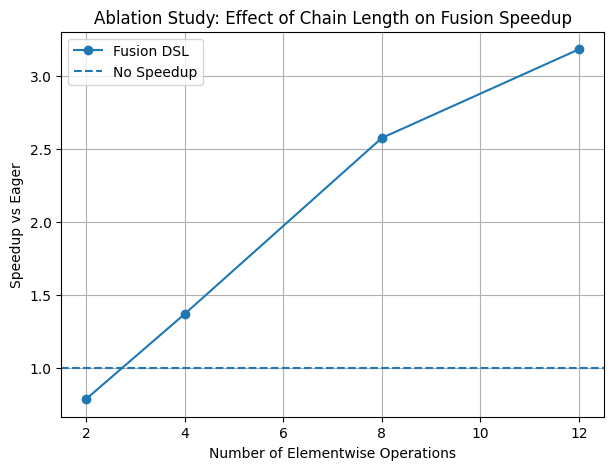

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    ablation_df["Chain Length"],
    ablation_df["DSL Speedup vs Eager"],
    marker="o",
    label="Fusion DSL"
)

plt.axhline(y=1.0, linestyle="--", label="No Speedup")
plt.xlabel("Number of Elementwise Operations")
plt.ylabel("Speedup vs Eager")
plt.title("Ablation Study: Effect of Chain Length on Fusion Speedup")
plt.legend()
plt.grid(True)
plt.savefig("chain_length_ablation.png", dpi=200, bbox_inches="tight")
plt.show()

Timing Stability

In [ ]:
def benchmark_stable(fn, x, warmup=10, iters=100, trials=5):
    trial_times = []

    for _ in range(trials):
        for _ in range(warmup):
            y = fn(x)

        torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(iters):
            y = fn(x)

        torch.cuda.synchronize()

        end = time.perf_counter()

        avg_time = (end - start) / iters
        trial_times.append(avg_time)

    return {
        "mean_ms": np.mean(trial_times) * 1000,
        "std_ms": np.std(trial_times) * 1000,
        "min_ms": np.min(trial_times) * 1000,
        "max_ms": np.max(trial_times) * 1000,
    }

In [ ]:
x = torch.randn(1_000_000, device=device)

eager_stats = benchmark_stable(eager_long_chain, x)
fused_stats = benchmark_stable(fused_long_chain, x)

print("Eager:", eager_stats)
print("Fusion DSL:", fused_stats)

Eager: {'mean_ms': np.float64(0.34795358000064874), 'std_ms': np.float64(0.0012676227380999348), 'min_ms': np.float64(0.3464684200002921), 'max_ms': np.float64(0.3494338300004074)}
Fusion DSL: {'mean_ms': np.float64(0.1068038119999528), 'std_ms': np.float64(0.0036392286389655437), 'min_ms': np.float64(0.10192891999963649), 'max_ms': np.float64(0.11074126999915279)}


In [ ]:
stable_results = []

for bench_name, versions in benchmarks.items():
    for n in sizes:
        x = torch.randn(n, device=device)

        for version_name, fn in versions.items():
            stats = benchmark_stable(fn, x)

            stable_results.append({
                "Benchmark": bench_name,
                "Tensor Size": n,
                "Version": version_name,
                "Mean Runtime (ms)": stats["mean_ms"],
                "Std Runtime (ms)": stats["std_ms"],
                "Min Runtime (ms)": stats["min_ms"],
                "Max Runtime (ms)": stats["max_ms"],
            })

stable_df = pd.DataFrame(stable_results)
stable_df

,Benchmark,Tensor Size,Version,Mean Runtime (ms),Std Runtime (ms),Min Runtime (ms),Max Runtime (ms)
0,Unary Short,10000,Eager,0.039282,0.007964,0.033846,0.055054
1,Unary Short,10000,torch.compile,0.102526,0.004937,0.098080,0.112051
2,Unary Short,10000,Fusion DSL,0.096183,0.001618,0.093012,0.097466
3,Unary Short,100000,Eager,0.032186,0.000878,0.030740,0.033225
4,Unary Short,100000,torch.compile,0.107257,0.009686,0.098691,0.122672
5,Unary Short,100000,Fusion DSL,0.113445,0.006307,0.107502,0.125061
6,Unary Short,1000000,Eager,0.136584,0.000099,0.136459,0.136761
7,Unary Short,1000000,torch.compile,0.101104,0.001934,0.098517,0.104138
8,Unary Short,1000000,Fusion DSL,0.131342,0.036415,0.100538,0.200426
9,Unary Short,10000000,Eager,1.380628,0.000456,1.380274,1.381458


In [ ]:
eager_means = (
    stable_df[stable_df["Version"] == "Eager"]
    .set_index(["Benchmark", "Tensor Size"])["Mean Runtime (ms)"]
)

stable_df["Speedup vs Eager"] = stable_df.apply(
    lambda row: eager_means.loc[(row["Benchmark"], row["Tensor Size"])] / row["Mean Runtime (ms)"],
    axis=1
)

stable_df

,Benchmark,Tensor Size,Version,Mean Runtime (ms),Std Runtime (ms),Min Runtime (ms),Max Runtime (ms),Speedup vs Eager
0,Unary Short,10000,Eager,0.039282,0.007964,0.033846,0.055054,1.000000
1,Unary Short,10000,torch.compile,0.102526,0.004937,0.098080,0.112051,0.383145
2,Unary Short,10000,Fusion DSL,0.096183,0.001618,0.093012,0.097466,0.408411
3,Unary Short,100000,Eager,0.032186,0.000878,0.030740,0.033225,1.000000
4,Unary Short,100000,torch.compile,0.107257,0.009686,0.098691,0.122672,0.300080
5,Unary Short,100000,Fusion DSL,0.113445,0.006307,0.107502,0.125061,0.283713
6,Unary Short,1000000,Eager,0.136584,0.000099,0.136459,0.136761,1.000000
7,Unary Short,1000000,torch.compile,0.101104,0.001934,0.098517,0.104138,1.350921
8,Unary Short,1000000,Fusion DSL,0.131342,0.036415,0.100538,0.200426,1.039907
9,Unary Short,10000000,Eager,1.380628,0.000456,1.380274,1.381458,1.000000


Final Experiment

In [ ]:
# simulate code that is split across separate user-defined functions,
# less "clean" structure than one straight-line elementwise chain
def helper_sin(x):
    return torch.sin(x)

def helper_cos(x):
    return torch.cos(x)

def helper_exp(x):
    return torch.exp(x)

def helper_relu(x):
    return torch.relu(x)

# baseline: fragmented eager version
def eager_fragmented_chain(x):
    y = helper_sin(x)
    y = helper_cos(y)
    y = helper_exp(y)
    y = helper_relu(y)
    return y


# direct torch.compile baseline
compiled_fragmented_chain = torch.compile(
    eager_fragmented_chain,
    mode="reduce-overhead"
)


# DSL version: user explicitly marks the fragmented chain as a fusion block
@fusion_block
def fused_fragmented_chain(x):
    y = helper_sin(x)
    y = helper_cos(y)
    y = helper_exp(y)
    y = helper_relu(y)
    return y

In [ ]:
fragmented_results = []

sizes = [10_000, 100_000, 1_000_000, 10_000_000]

for n in sizes:
    x = torch.randn(n, device=device)

    eager_time = benchmark(eager_fragmented_chain, x)
    compiled_time = benchmark(compiled_fragmented_chain, x)
    fused_time = benchmark(fused_fragmented_chain, x)

    eager_mem = benchmark_memory(eager_fragmented_chain, x)
    compiled_mem = benchmark_memory(compiled_fragmented_chain, x)
    fused_mem = benchmark_memory(fused_fragmented_chain, x)

    fragmented_results.extend([
        {
            "Tensor Size": n,
            "Version": "Eager Fragmented",
            "Runtime (ms)": eager_time * 1000,
            "Peak Mem (MB)": eager_mem,
            "Speedup vs Eager": 1.0
        },
        {
            "Tensor Size": n,
            "Version": "torch.compile Fragmented",
            "Runtime (ms)": compiled_time * 1000,
            "Peak Mem (MB)": compiled_mem,
            "Speedup vs Eager": eager_time / compiled_time
        },
        {
            "Tensor Size": n,
            "Version": "Fusion DSL Fragmented",
            "Runtime (ms)": fused_time * 1000,
            "Peak Mem (MB)": fused_mem,
            "Speedup vs Eager": eager_time / fused_time
        }
    ])

fragmented_df = pd.DataFrame(fragmented_results)
fragmented_df

,Tensor Size,Version,Runtime (ms),Peak Mem (MB),Speedup vs Eager
0,10000,Eager Fragmented,0.050003,3.931641,1.000000
1,10000,torch.compile Fragmented,0.092598,3.854492,0.540004
2,10000,Fusion DSL Fragmented,0.085705,3.854492,0.583435
3,100000,Eager Fragmented,0.031739,4.961426,1.000000
4,100000,torch.compile Fragmented,0.094428,4.197754,0.336117
5,100000,Fusion DSL Fragmented,0.095587,4.197754,0.332041
6,1000000,Eager Fragmented,0.140486,16.186035,1.000000
7,1000000,torch.compile Fragmented,0.096662,8.556152,1.453375
8,1000000,Fusion DSL Fragmented,0.106574,8.556152,1.318208
9,10000000,Eager Fragmented,1.347888,118.256836,1.000000


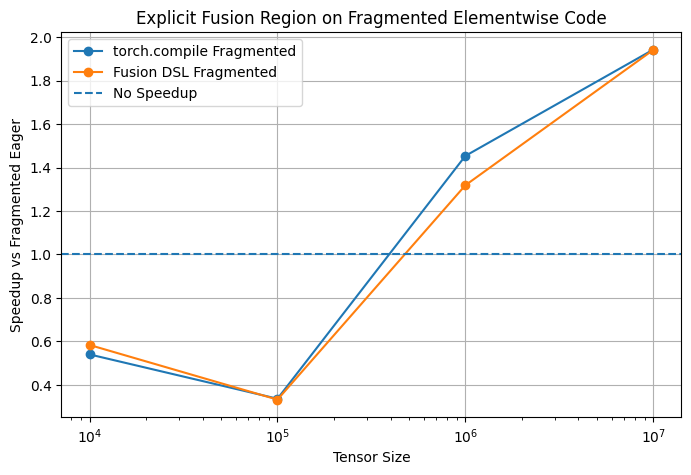

In [ ]:
plt.figure(figsize=(8, 5))

for version_name in fragmented_df["Version"].unique():
    if version_name == "Eager Fragmented":
        continue

    subset = fragmented_df[fragmented_df["Version"] == version_name]

    plt.plot(
        subset["Tensor Size"],
        subset["Speedup vs Eager"],
        marker="o",
        label=version_name
    )

plt.axhline(y=1.0, linestyle="--", label="No Speedup")
plt.xscale("log")
plt.xlabel("Tensor Size")
plt.ylabel("Speedup vs Fragmented Eager")
plt.title("Explicit Fusion Region on Fragmented Elementwise Code")
plt.legend()
plt.grid(True)
plt.savefig("fragmented_fusion_speedup.png", dpi=200, bbox_inches="tight")
plt.show()

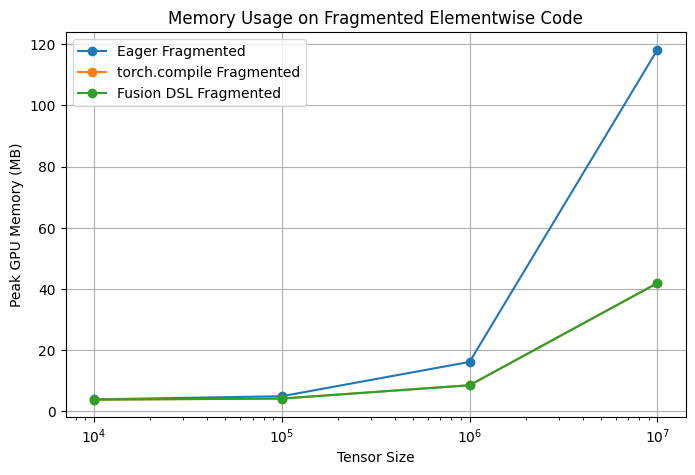

In [ ]:
plt.figure(figsize=(8, 5))

for version_name in fragmented_df["Version"].unique():
    subset = fragmented_df[fragmented_df["Version"] == version_name]

    plt.plot(
        subset["Tensor Size"],
        subset["Peak Mem (MB)"],
        marker="o",
        label=version_name
    )

plt.xscale("log")
plt.xlabel("Tensor Size")
plt.ylabel("Peak GPU Memory (MB)")
plt.title("Memory Usage on Fragmented Elementwise Code")
plt.legend()
plt.grid(True)
plt.savefig("fragmented_memory.png", dpi=200, bbox_inches="tight")
plt.show()